In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
column_names = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

df = pd.read_csv(
    "/kaggle/input/datasets/luv2004/adult-income-dataset/adult.data",
    names=column_names,
    skipinitialspace=True
)

df.replace("?", np.nan, inplace=True)

df.dropna(inplace=True)

df["income_binary"] = (
    df["income"]
    .astype(str)
    .str.contains(">50K")
    .astype(int)
)

X = df.drop(
    columns=[
        "income",
        "income_binary"
    ]
)

y = df["income_binary"]

In [3]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

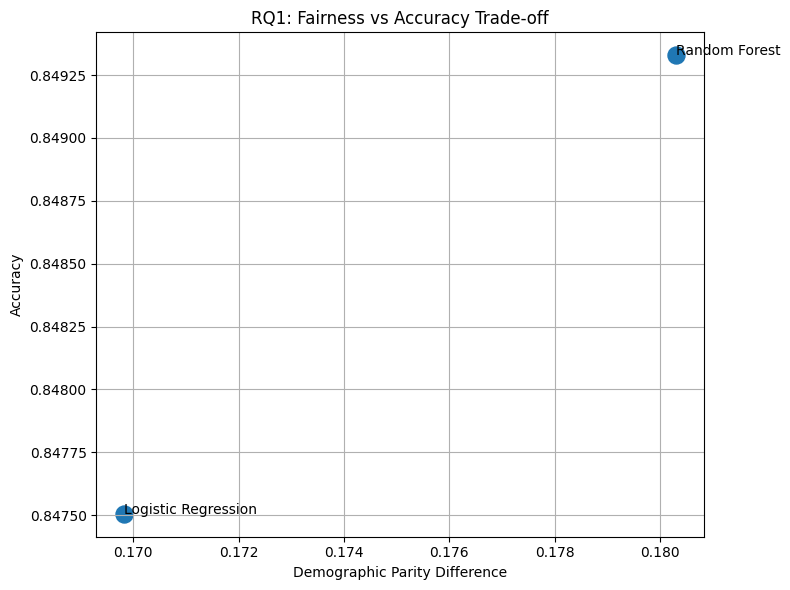

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    rq1["DP_Difference"],
    rq1["Accuracy"],
    s=150
)

for i in range(len(rq1)):
    plt.annotate(
        rq1["Model"][i],
        (
            rq1["DP_Difference"][i],
            rq1["Accuracy"][i]
        )
    )

plt.xlabel("Demographic Parity Difference")
plt.ylabel("Accuracy")
plt.title("RQ1: Fairness vs Accuracy Trade-off")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figure_rq1.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

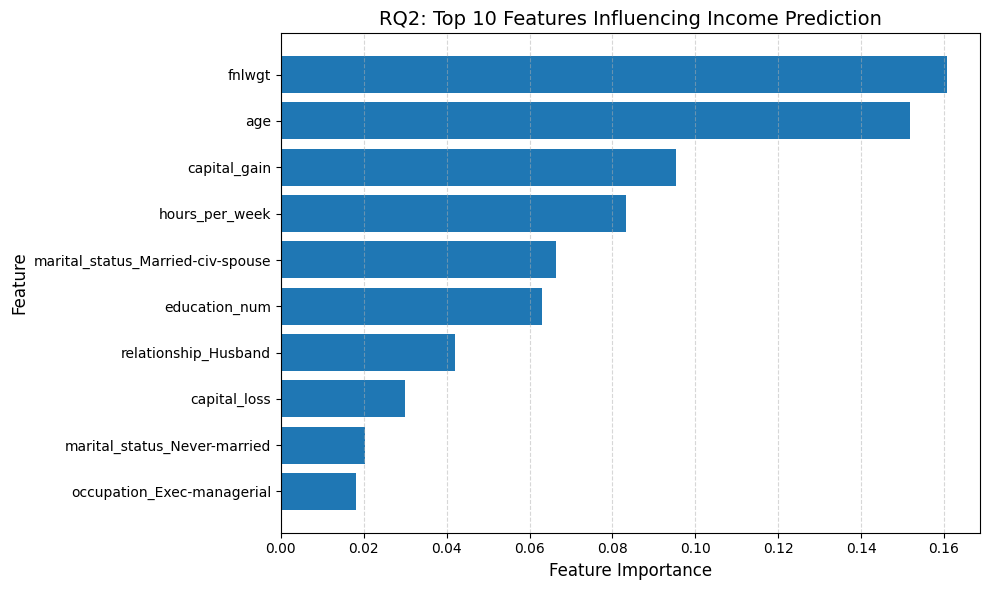

PDF saved successfully


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load feature importance table
rq2 = pd.read_csv("table_rq2_feature_importance.csv")

# Top 10 features
top10 = rq2.head(10)

# Create publication-quality figure
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"][::-1],
    top10["Importance"][::-1]
)

plt.xlabel(
    "Feature Importance",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "RQ2: Top 10 Features Influencing Income Prediction",
    fontsize=14
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

# Save PDF
plt.savefig(
    "figure_rq2_feature_importance.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PDF saved successfully")


Gender Bias Table
      sex  Actual_High_Income_Rate  Predicted_High_Income_Rate  Bias_Gap
0  Female                 0.119411                    0.093496 -0.025915
1    Male                 0.311685                    0.273801 -0.037884


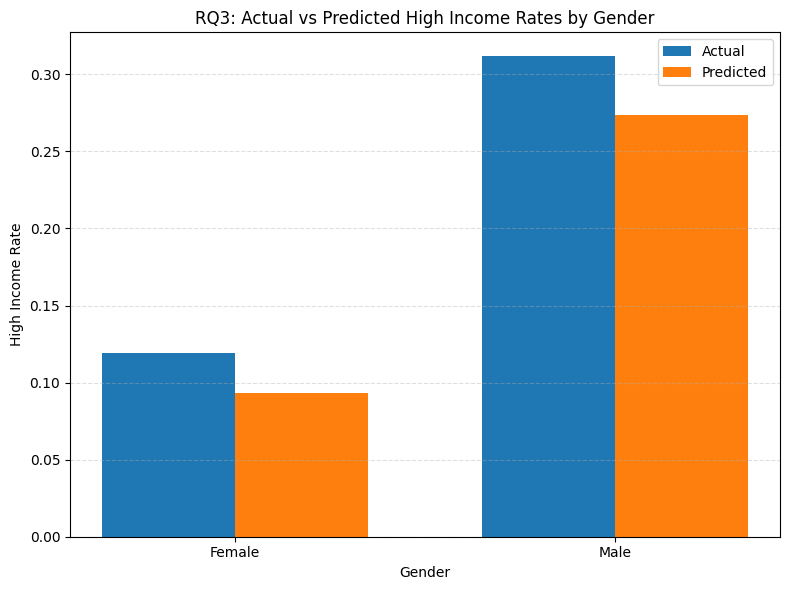


Race Bias Table
                 race  Actual_High_Income_Rate  Predicted_High_Income_Rate  \
0  Amer-Indian-Eskimo                 0.093750                    0.046875   
1  Asian-Pac-Islander                 0.236559                    0.241935   
2               Black                 0.143113                    0.082290   
3               Other                 0.078947                    0.105263   
4               White                 0.263980                    0.231199   

   Bias_Gap  
0 -0.046875  
1  0.005376  
2 -0.060823  
3  0.026316  
4 -0.032781  


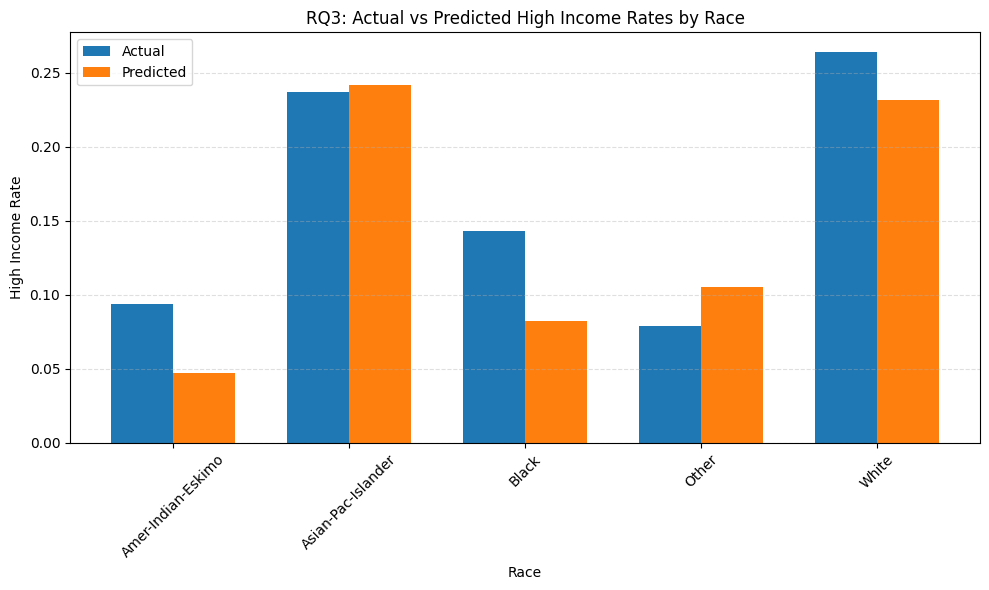


Generated Files:
figure_rq1.pdf
table_rq3_race_bias.csv
table_rq1.csv
figure_rq2_feature_importance.pdf
table_rq2_feature_importance.csv
figure_rq3_race_bias.pdf
figure_rq3_gender_bias.pdf
table_rq3_gender_bias.csv


In [11]:
# =====================================================
# RQ3: Historical Bias Analysis
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Create prediction results dataframe
# -----------------------------------------------------

results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = rf_pred

# =====================================================
# GENDER BIAS TABLE
# =====================================================

gender_bias = (
    results
    .groupby("sex")
    .agg(
        Actual_High_Income_Rate=("Actual","mean"),
        Predicted_High_Income_Rate=("Predicted","mean")
    )
    .reset_index()
)

gender_bias["Bias_Gap"] = (
    gender_bias["Predicted_High_Income_Rate"]
    -
    gender_bias["Actual_High_Income_Rate"]
)

gender_bias.to_csv(
    "table_rq3_gender_bias.csv",
    index=False
)

print("\nGender Bias Table")
print(gender_bias)

# =====================================================
# GENDER BIAS FIGURE
# =====================================================

plt.figure(figsize=(8,6))

x = np.arange(len(gender_bias))
width = 0.35

plt.bar(
    x - width/2,
    gender_bias["Actual_High_Income_Rate"],
    width,
    label="Actual"
)

plt.bar(
    x + width/2,
    gender_bias["Predicted_High_Income_Rate"],
    width,
    label="Predicted"
)

plt.xticks(
    x,
    gender_bias["sex"]
)

plt.ylabel("High Income Rate")
plt.xlabel("Gender")

plt.title(
    "RQ3: Actual vs Predicted High Income Rates by Gender"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "figure_rq3_gender_bias.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# RACE BIAS TABLE
# =====================================================

race_bias = (
    results
    .groupby("race")
    .agg(
        Actual_High_Income_Rate=("Actual","mean"),
        Predicted_High_Income_Rate=("Predicted","mean")
    )
    .reset_index()
)

race_bias["Bias_Gap"] = (
    race_bias["Predicted_High_Income_Rate"]
    -
    race_bias["Actual_High_Income_Rate"]
)

race_bias.to_csv(
    "table_rq3_race_bias.csv",
    index=False
)

print("\nRace Bias Table")
print(race_bias)

# =====================================================
# RACE BIAS FIGURE
# =====================================================

plt.figure(figsize=(10,6))

x = np.arange(len(race_bias))
width = 0.35

plt.bar(
    x - width/2,
    race_bias["Actual_High_Income_Rate"],
    width,
    label="Actual"
)

plt.bar(
    x + width/2,
    race_bias["Predicted_High_Income_Rate"],
    width,
    label="Predicted"
)

plt.xticks(
    x,
    race_bias["race"],
    rotation=45
)

plt.ylabel("High Income Rate")
plt.xlabel("Race")

plt.title(
    "RQ3: Actual vs Predicted High Income Rates by Race"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "figure_rq3_race_bias.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# VERIFY OUTPUTS
# =====================================================

import os

print("\nGenerated Files:")

for f in os.listdir():
    if (
        f.endswith(".csv")
        or
        f.endswith(".pdf")
    ):
        print(f)

      Metric     Value
0   Accuracy  0.849329
1  DP_Gender  0.180305
2  EO_Gender  0.049704
3    DP_Race  0.195060
4    EO_Race  0.393939


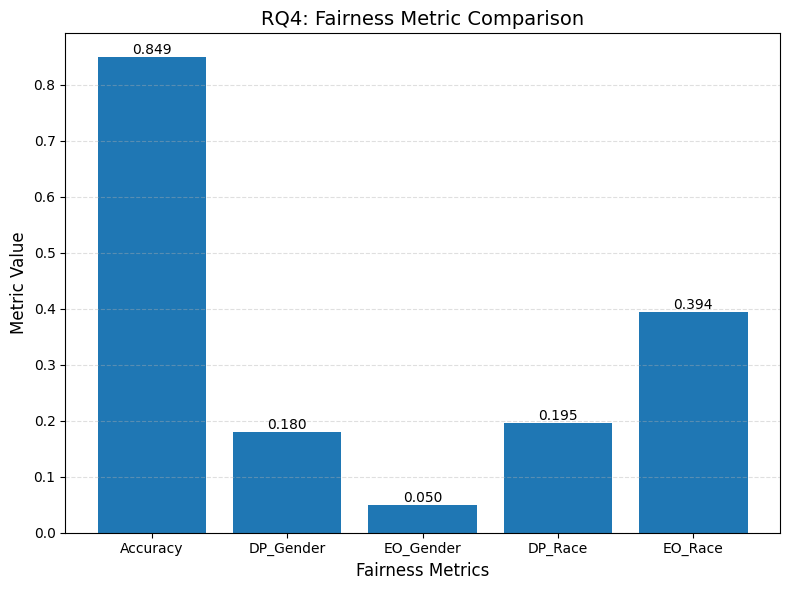


Generated Files:
table_rq4_fairness_metrics.csv
figure_rq1.pdf
table_rq3_race_bias.csv
table_rq1.csv
figure_rq2_feature_importance.pdf
figure_rq4_fairness_comparison.pdf
table_rq2_feature_importance.csv
figure_rq3_race_bias.pdf
table_rq5_allocation_results.csv
figure_rq3_gender_bias.pdf
table_rq3_gender_bias.csv


In [15]:
# =====================================================
# RQ4: Fairness Metrics Comparison
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# =====================================================
# FAIRNESS FUNCTIONS
# =====================================================

def demographic_parity_difference(
    sensitive,
    predictions
):

    groups = sensitive.unique()

    rates = []

    for g in groups:

        idx = sensitive == g

        rates.append(
            predictions[idx].mean()
        )

    return abs(
        max(rates)
        -
        min(rates)
    )


def equal_opportunity_difference(
    sensitive,
    y_true,
    y_pred
):

    groups = sensitive.unique()

    tpr_values = []

    for g in groups:

        idx = (
            (sensitive == g)
            &
            (y_true == 1)
        )

        if idx.sum() == 0:
            continue

        tpr = (
            y_pred[idx] == 1
        ).mean()

        tpr_values.append(tpr)

    return abs(
        max(tpr_values)
        -
        min(tpr_values)
    )

# =====================================================
# CALCULATE METRICS
# =====================================================

accuracy = accuracy_score(
    y_test,
    rf_pred
)

dp_gender = demographic_parity_difference(
    X_test["sex"],
    rf_pred
)

eo_gender = equal_opportunity_difference(
    X_test["sex"],
    y_test.values,
    rf_pred
)

dp_race = demographic_parity_difference(
    X_test["race"],
    rf_pred
)

eo_race = equal_opportunity_difference(
    X_test["race"],
    y_test.values,
    rf_pred
)

# =====================================================
# CREATE TABLE
# =====================================================

rq4 = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "DP_Gender",
        "EO_Gender",
        "DP_Race",
        "EO_Race"
    ],

    "Value":[
        accuracy,
        dp_gender,
        eo_gender,
        dp_race,
        eo_race
    ]
})

print(rq4)

rq4.to_csv(
    "table_rq4_fairness_metrics.csv",
    index=False
)

# =====================================================
# CREATE PDF FIGURE
# =====================================================

plt.figure(figsize=(8,6))

bars = plt.bar(
    rq4["Metric"],
    rq4["Value"]
)

plt.ylabel(
    "Metric Value",
    fontsize=12
)

plt.xlabel(
    "Fairness Metrics",
    fontsize=12
)

plt.title(
    "RQ4: Fairness Metric Comparison",
    fontsize=14
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Add values on bars

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "figure_rq4_fairness_comparison.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# VERIFY OUTPUTS
# =====================================================

import os

print("\nGenerated Files:")

for file in os.listdir():

    if (
        file.endswith(".csv")
        or
        file.endswith(".pdf")
    ):
        print(file)

   Method  Utility  Male_Allocation_Rate  Female_Allocation_Rate
0  Greedy      898              0.254859                0.086382
1    Fair      735              0.148339                0.306402


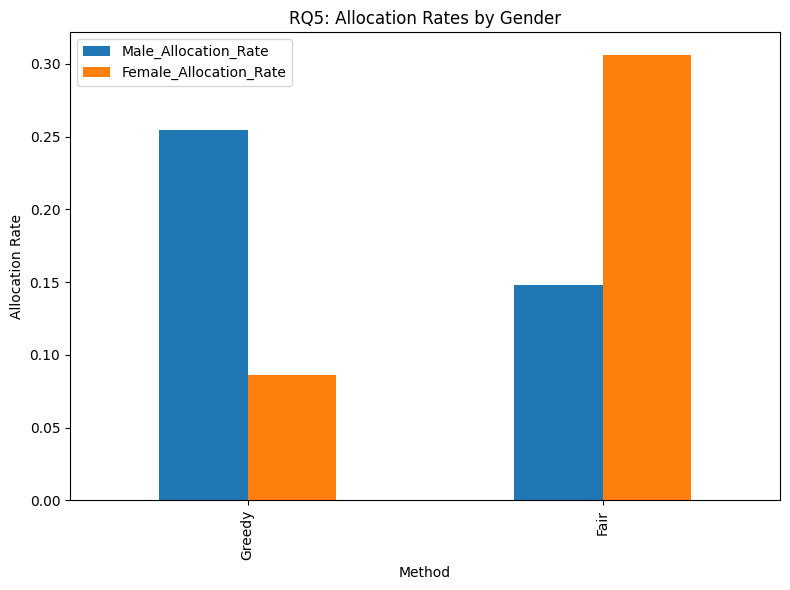

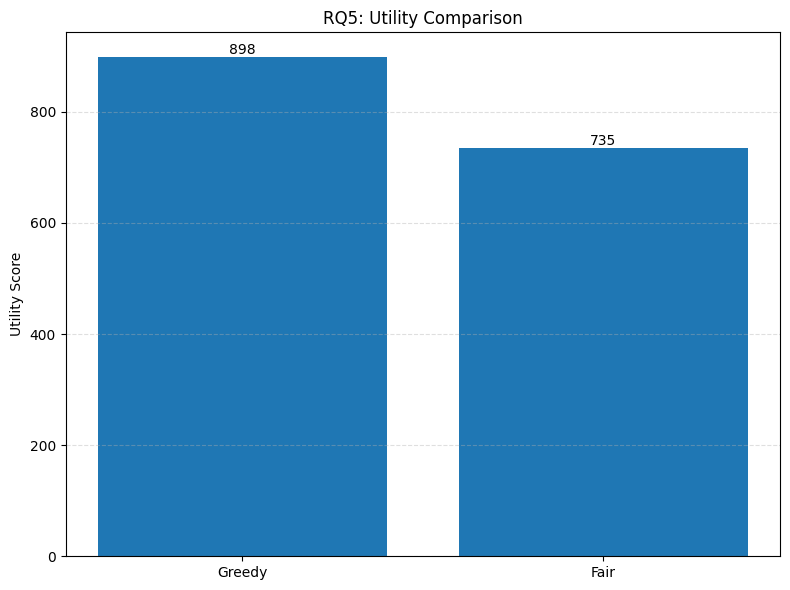


Generated Files:
table_rq4_fairness_metrics.csv
figure_rq1.pdf
table_rq3_race_bias.csv
table_rq1.csv
figure_rq2_feature_importance.pdf
figure_rq4_fairness_comparison.pdf
table_rq2_feature_importance.csv
figure_rq3_race_bias.pdf
table_rq5_allocation_results.csv
figure_rq3_gender_bias.pdf
figure_rq5_fairness_vs_utility.pdf
figure_rq5_allocation_rates.pdf
table_rq3_gender_bias.csv


In [17]:
# =====================================================
# RQ5: Fair Resource Allocation Analysis
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Predict Probabilities
# -----------------------------------------------------

probabilities = rf_model.predict_proba(
    X_test
)[:,1]

results = X_test.copy()

results["Probability"] = probabilities
results["True_Label"] = y_test.values

# -----------------------------------------------------
# Allocation Settings
# -----------------------------------------------------

allocation_rate = 0.20

n_allocate = int(
    len(results) * allocation_rate
)

# -----------------------------------------------------
# Greedy Allocation
# -----------------------------------------------------

greedy = results.copy()

greedy = greedy.sort_values(
    by="Probability",
    ascending=False
)

greedy["Allocated"] = 0

greedy.iloc[
    :n_allocate,
    greedy.columns.get_loc("Allocated")
] = 1

# -----------------------------------------------------
# Fair Allocation
# -----------------------------------------------------

fair = results.copy()

fair["Allocated"] = 0

male = fair[
    fair["sex"] == "Male"
].sort_values(
    by="Probability",
    ascending=False
)

female = fair[
    fair["sex"] == "Female"
].sort_values(
    by="Probability",
    ascending=False
)

male_allocate = int(n_allocate/2)
female_allocate = int(n_allocate/2)

fair.loc[
    male.index[:male_allocate],
    "Allocated"
] = 1

fair.loc[
    female.index[:female_allocate],
    "Allocated"
] = 1

# -----------------------------------------------------
# Utility Function
# -----------------------------------------------------

def utility_score(df):

    return (
        (
            df["Allocated"] == 1
        )
        &
        (
            df["True_Label"] == 1
        )
    ).sum()

# -----------------------------------------------------
# Allocation Rates
# -----------------------------------------------------

greedy_rates = (
    greedy
    .groupby("sex")
    ["Allocated"]
    .mean()
)

fair_rates = (
    fair
    .groupby("sex")
    ["Allocated"]
    .mean()
)

# -----------------------------------------------------
# Utility Scores
# -----------------------------------------------------

greedy_utility = utility_score(
    greedy
)

fair_utility = utility_score(
    fair
)

# -----------------------------------------------------
# Create CSV Table
# -----------------------------------------------------

rq5 = pd.DataFrame({

    "Method":[
        "Greedy",
        "Fair"
    ],

    "Utility":[
        greedy_utility,
        fair_utility
    ],

    "Male_Allocation_Rate":[
        greedy_rates["Male"],
        fair_rates["Male"]
    ],

    "Female_Allocation_Rate":[
        greedy_rates["Female"],
        fair_rates["Female"]
    ]
})

rq5.to_csv(
    "table_rq5_allocation_results.csv",
    index=False
)

print(rq5)

# =====================================================
# FIGURE 1
# Allocation Rates
# =====================================================

plot_df = rq5.set_index(
    "Method"
)[
    [
        "Male_Allocation_Rate",
        "Female_Allocation_Rate"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(8,6)
)

plt.ylabel(
    "Allocation Rate"
)

plt.title(
    "RQ5: Allocation Rates by Gender"
)

plt.tight_layout()

plt.savefig(
    "figure_rq5_allocation_rates.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# FIGURE 2
# Utility Comparison
# =====================================================

plt.figure(figsize=(8,6))

bars = plt.bar(
    rq5["Method"],
    rq5["Utility"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.ylabel(
    "Utility Score"
)

plt.title(
    "RQ5: Utility Comparison"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "figure_rq5_fairness_vs_utility.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# VERIFY OUTPUTS
# =====================================================

import os

print("\nGenerated Files:")

for f in os.listdir():

    if (
        f.endswith(".csv")
        or
        f.endswith(".pdf")
    ):
        print(f)